
#**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

##**Edición 2026**

---
## Trabajo práctico entregable - Parte 1

## Grupo 14
- MARIA JOSE KANAGUSUKU
- NICOLAS URIEL MANSUTTI
- RAFAEL ANDRES PIGNATA
- MARIA VALERIA SIEYRA

In [1]:
import io
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy
import pandas as pd
import seaborn

seaborn.set_context('talk')

## Lectura del dataset

En la notebook 00 se explican los detalles de la siguiente sección.

In [2]:
# cargamos los datos
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/master/sysarmy_survey_2026_processed.csv'
df = pd.read_csv(url)

En la siguiente celda limpiamos los datos de la siguiente manera:

1.   Filtramos a partir de los salarios brutos y netos más grandes que el percentil 5% y que no superaran el percentil 95%
2.   Eliminamos los salarios netos mayores a los salarios brutos porque es un absurdo
1.   Eliminamos los NaN







In [3]:
bruto_quartile_top= df.salary_monthly_BRUTO.quantile(0.95)
neto_quartile_top= df.salary_monthly_NETO.quantile(0.95)

bruto_quartile_bottom= df.salary_monthly_BRUTO.quantile(0.05)
neto_quartile_bottom= df.salary_monthly_NETO.quantile(0.05)

df_salary_filtered= df[(df.salary_monthly_BRUTO < bruto_quartile_top) #chau cola 95%
                  & (df.salary_monthly_NETO < neto_quartile_top) #chau cola 95%
                  & (df.salary_monthly_NETO <= df.salary_monthly_BRUTO) #chau netos más grandes (absurdo)
                  & (df.salary_monthly_NETO >= neto_quartile_bottom) #chau cola 5%
                  & (df.salary_monthly_BRUTO >= bruto_quartile_bottom) #chau cola 5%
                  & (df.salary_monthly_BRUTO.notna()) #chau absurdo
                  & (df.salary_monthly_NETO.notna())].copy() #chau absurdo

En la siguiente celda dividimos los salarios netos por 1.e6 para que los números no sean tan grandes (es más fácil de leer)

In [4]:
factor= 1000000 # 1M
df_salary_filtered.salary_monthly_NETO= df_salary_filtered["salary_monthly_NETO"]/factor
df_salary_filtered.salary_monthly_BRUTO= df_salary_filtered["salary_monthly_BRUTO"]/factor
df_salary_filtered.salary_monthly_NETO.describe()

,salary_monthly_NETO
count,4014.000000
mean,3.003674
std,1.365603
min,0.996000
25%,1.956020
50%,2.721141
75%,3.819138
max,7.200000


# Ejercicio 1 - Análisis descriptivo

Responder a la pregunta: **¿Cuáles son los lenguajes de programación asociados a los mejores salarios?**

Para ello:
1. Seleccionar las columnas relevantes para analizar.
2. Seleccionar las filas relevantes para analizar. Esto incluye la eliminación de valores extremos y erróneos, pero también puede enfocar el análisis en una sub-población. Por ejemplo, se pueden limitar a personas con un salario mayor que 300000 pesos, o a las personas que trabajan sólo en "Data Science", pero deben justificar su elección y reformular la pregunta inicial de ser necesario.
  * Obtener una lista de los lenguajes de programación más populares. Decidir cuántos y cuáles seleccionan para incluir en el análisis.
  * Para cada una de las otras columnas del punto anterior, elegir los rangos o valores seleccionan para incluir en el análisis.
3. Seleccionar métricas que ayuden a responder la pregunta, y los métodos para analizarlas. Elegir UNA de las siguientes opciones:
  * Comparar las distribuciones de salario para cada lenguaje utilizando visualizaciones. Como la visualización es el producto final, debe ser clara y mostrar información relevante.
  * Comparar medidas de estadística descriptiva sobre la distribución de salario para cada lenguaje. Sean creativos, la estadística descriptiva nos permite decir cosas como: "el 10% de los mejores sueldos los ganan, en su mayoría, programadores que saben kotlin!" (donde *mayoría* es un término medio engañoso que sólo significa más del 50%). Para comparar múltiples lenguajes, les recomendamos usar también visualizaciones.
  * Comparar probabilidades. Por ejemplo: "Si sabés Python o Java, tenés un 30% más de chances de ganar arriba de 1000K".

Si lo consideran necesario, realicen varias iteraciones. Es decir, si encuentran que las distribuciones de los lenguajes de programación que seleccionaron inicialmente no son muy diferentes, pueden re-hacer el análisis usando sólo los lenguajes de programación que son diferentes.

Las columnas que vamos a tener en cuenta para el ejercicio 1 son los lenguajes de programación y los salarios netos

In [5]:
relevant_columns = ['tools_programming_languages', 'salary_monthly_NETO']

### Conteo de frecuencias de los lenguajes de programación

La columna que contiene información sobre los lenguajes de programación utilizados es `tools_programming_languages`. Sus valores son strings con los lenguajes seleccionados separados por comas.



In [6]:
df.tools_programming_languages[:3]

,tools_programming_languages
0,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL"
1,".NET, C#, HTML, Javascript, SQL"
2,"Go, SQL"


Las siguientes celdas de código separan estos lenguajes de programación y cuentan la frecuencia con la que aparecen.

In [7]:
# Convert the comma-separated string of languages to a list of string.
# Remove 'ninguno de los anteriores' option, spaces and training commas.
def split_languages(languages_str):
  if not isinstance(languages_str, str):
    return []
  # Remove 'other' option
  languages_str = languages_str.lower()\
    .replace('ninguno de los anteriores', '')\
    .replace('no soy perfil técnico', '')\

  # Split string into list of items
  # Remove spaces and commas for each item
  return [lang.strip().replace(',', '')
          for lang in languages_str.split()]

# Create a new column with the list of languages
df_salary_filtered.loc[:, 'cured_programming_languages'] = df_salary_filtered.tools_programming_languages\
    .apply(split_languages)
if 'cured_programming_languages' not in relevant_columns:
    relevant_columns.append('cured_programming_languages')

# Duplicate each row of df for each programming language
# mentioned in the response.
# We only include in df_lang the columns we are going to analyze later, so we
# don't duplicate innecesary information.
df_lang = df_salary_filtered.cured_programming_languages\
    .apply(pd.Series).stack()\
    .reset_index(level=-1, drop=True).to_frame()\
    .join(df_salary_filtered[relevant_columns])\
    .rename(columns={0: 'programming_language'})
# Horrible programming style! But a lot of data science code can be written with
# as concatenations of functions (pipelines), and there's no elegant way of
# doing that on Python.
df_lang[:5]

,programming_language,tools_programming_languages,salary_monthly_NETO,cured_programming_languages
0,.net,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2.4,"[.net, c#, css, go, html, java, javascript, sql]"
0,c#,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2.4,"[.net, c#, css, go, html, java, javascript, sql]"
0,css,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2.4,"[.net, c#, css, go, html, java, javascript, sql]"
0,go,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2.4,"[.net, c#, css, go, html, java, javascript, sql]"
0,html,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2.4,"[.net, c#, css, go, html, java, javascript, sql]"


En la columna `programming_language` se encuentra cada lenguaje por separado. Notar que si una respuesta contenía 3 lenguajes, como `"HTML, Javascript, Python"`, la fila ha sido replicada 3 veces. Por ello, hay tres filas con índice 1.

In [8]:
df_total_lang= df_lang.copy()

Una vez separados los lenguajes de programación, en la siguiente celda vamos a considerar las personas que tienen salario más alto. Para ello consideramos los salarios que son mayores o iguales al 95%.

In [9]:
neto_quartile_bottom = df_lang.salary_monthly_NETO.quantile(0.95)

df_lang= df_lang[(df_lang.salary_monthly_NETO >= neto_quartile_bottom) #hola cola 5%
                 ].copy()
df_lang[:5]

,programming_language,tools_programming_languages,salary_monthly_NETO,cured_programming_languages
6,.net,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",7.2,"[.net, c#, css, go, html, java, javascript, sql]"
6,c#,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",7.2,"[.net, c#, css, go, html, java, javascript, sql]"
6,css,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",7.2,"[.net, c#, css, go, html, java, javascript, sql]"
6,go,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",7.2,"[.net, c#, css, go, html, java, javascript, sql]"
6,html,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",7.2,"[.net, c#, css, go, html, java, javascript, sql]"


In [10]:
language_count = df_lang.programming_language.value_counts()\
    .reset_index()\
    .rename(columns={'index': 'language', 'programming_language': 'frequency'})
#language_count[:15]
len(language_count.value_counts())

38

A partir de la celda anterior podemos ver que la cantidad de lenguajes utilizados por las personas más "ricas" de nuestra muestra son 38. Sin embargo, nos quedamos con los 10 más populares

In [11]:
# Calculate the total number of users (rows) in df_lang_money_filtered
total_users = len(df_lang)

# Calculate the percentage of users for each language
language_count['percentage'] = round((language_count['count'] / total_users) * 100,3)

print("Lenguajes con más del 5% de usuarios:")
display(language_count[language_count['percentage'] > 5])

print("\nLenguajes con más del 10% de usuarios:")
display(language_count[language_count['percentage'] > 10])

Lenguajes con más del 5% de usuarios:


,frequency,count,percentage
0,javascript,80,13.913
1,python,76,13.217
2,sql,67,11.652
3,html,54,9.391
4,typescript,53,9.217
5,java,42,7.304
6,bash/shell,37,6.435
7,css,33,5.739



Lenguajes con más del 10% de usuarios:


,frequency,count,percentage
0,javascript,80,13.913
1,python,76,13.217
2,sql,67,11.652


/tmp/ipykernel_11283/3888163185.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = seaborn.boxplot(data=df_top_languages,


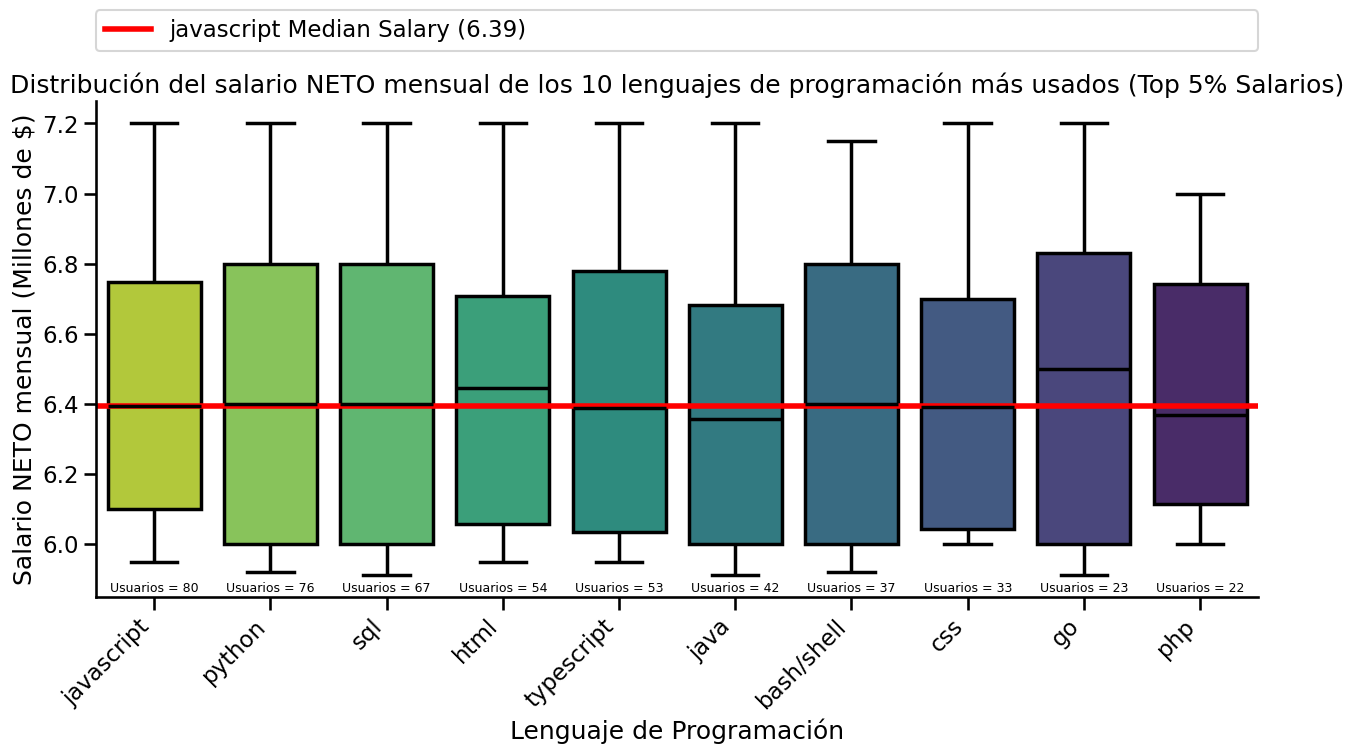

In [12]:
# Select the top N most frequent languages for better visualization
top_n_languages = 10
most_frequent_languages = language_count.head(top_n_languages)['frequency'].tolist()
salary_col= 'salary_monthly_NETO'

# Filter df_lang_money_filtered to include only these languages
df_top_languages = df_lang[df_lang['programming_language'].isin(most_frequent_languages)]
# Create the box plot
plt.figure(figsize=(13, 8))
ax = seaborn.boxplot(data=df_top_languages,
                   x='programming_language',
                   y=salary_col,
                   palette='viridis_r',
                   linewidth=2.5, # Adjust line thickness
                   linecolor='k',  # Set line color
                   order=most_frequent_languages) # Explicitly set the order of languages
plt.xticks(rotation=45, ha='right')
plt.title(f'Distribución del salario NETO mensual de los {top_n_languages} lenguajes de programación más usados (Top 5% Salarios)')
plt.xlabel('Lenguaje de Programación')
plt.ylabel('Salario NETO mensual (Millones de $)')
seaborn.despine()

# Add user counts above each violin plot
for i, lang in enumerate(most_frequent_languages):
    # Get the count for the current language from the language_count DataFrame
    count = language_count[language_count['frequency'] == lang]['count'].iloc[0]
    ax.text(i, ax.get_ylim()[1] * (0.806), f'Usuarios = {count}', ha='center', va='bottom', fontsize=9, color='black')

# Add vertical lines for percentage thresholds
go_index = most_frequent_languages.index('css')
net_index = most_frequent_languages.index('html')

#chau ax.axvline(x=go_index, color='blue', linestyle='--', linewidth=2, label='Threshold >5% Users (css)')
#chau ax.axvline(x=net_index, color='red', linestyle='--', linewidth=2, label='Threshold >10% Users (html)')

# Calculate median salary for the most popular language (javascript) and add horizontal line
pop_median_salary = df_top_languages[df_top_languages['programming_language'] == 'javascript'][salary_col].median()
ax.axhline(y=pop_median_salary, color='red', linestyle='-', linewidth=4, label=f'javascript Median Salary ({pop_median_salary:,.2f})')

plt.legend(loc='lower left', bbox_to_anchor=(0, 1.1, 1, 0.3), mode="expand", borderaxespad=0, ncol=3)
plt.tight_layout()
plt.show()

Quisieramos ver la probabilidad de ser rico por saber cierto lenguaje de programacion. Para eso necesitamos contar la cantidad de gente "común" (ricos y no ricos) que sabe los 10 lenguajes mostrados arriba.
Recordemos que df_total_lang tiene el dataframe con salarios limpios y la columna de lenguajes.

In [13]:
rich_languages=[l for l in most_frequent_languages[:10] ]


languages_rich_total_count = [(l, df_total_lang.programming_language.value_counts()[l]) for l in rich_languages ] #total amount of people of a certain language

languages_rich_total_count



[('javascript', np.int64(1500)),
 ('python', np.int64(1411)),
 ('sql', np.int64(1812)),
 ('html', np.int64(1135)),
 ('typescript', np.int64(897)),
 ('java', np.int64(666)),
 ('bash/shell', np.int64(724)),
 ('css', np.int64(721)),
 ('go', np.int64(205)),
 ('php', np.int64(445))]

Ahora ya tenemos la cantidad total de gente que sabe cada uno de los 10 lenguajes de interes. Veamos las probabilidades de ser rico en base a cada uno.

In [14]:
# sea l un cierto lenguaje de interés
#P (rico | l) = P(rico and l) / P(l) = len(l_programers in df_lang ) / len(l_programers in df_total_lang)
#rich_probab= [(l, l for l in languages_rich_total_count[1])]
rich_probab=[]
for i in range(0,10):
  l=rich_languages[i]
  p= df_lang.programming_language.value_counts()[l]/languages_rich_total_count[i][1]
  rich_probab.append((rich_languages[i],p*100))
#print(rich_probab*100)
rich_probab

[('javascript', np.float64(5.333333333333334)),
 ('python', np.float64(5.386250885896527)),
 ('sql', np.float64(3.69757174392936)),
 ('html', np.float64(4.757709251101322)),
 ('typescript', np.float64(5.908584169453734)),
 ('java', np.float64(6.306306306306306)),
 ('bash/shell', np.float64(5.110497237569061)),
 ('css', np.float64(4.5769764216366156)),
 ('go', np.float64(11.219512195121952)),
 ('php', np.float64(4.943820224719101))]

/tmp/ipykernel_11283/3123175606.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  seaborn.barplot(x='language', y='probability', data=rich_probab_df, palette='viridis_r')


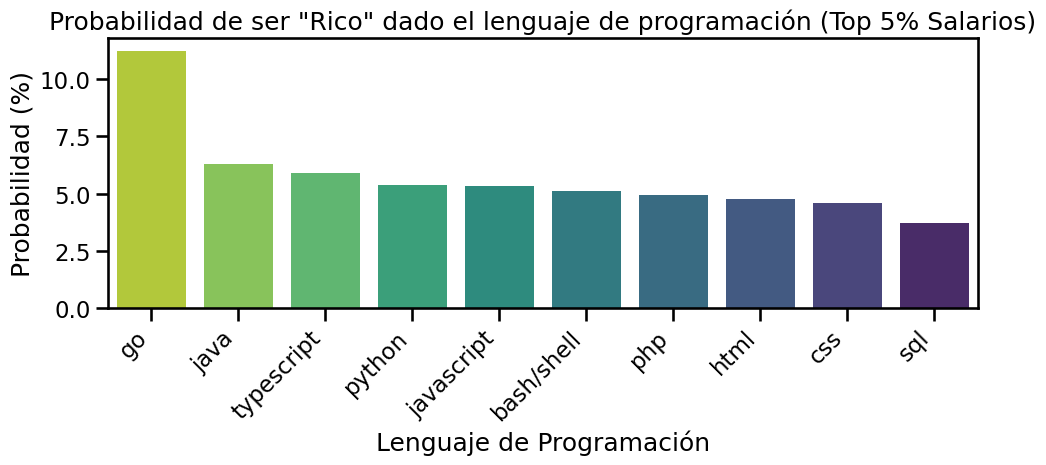

In [15]:
rich_probab_df = pd.DataFrame(rich_probab, columns=['language', 'probability'])
rich_probab_df = rich_probab_df.sort_values(by='probability', ascending=False)

plt.figure(figsize=(10, 5))
seaborn.barplot(x='language', y='probability', data=rich_probab_df, palette='viridis_r')
plt.xticks(rotation=45, ha='right')
plt.title('Probabilidad de ser "Rico" dado el lenguaje de programación (Top 5% Salarios)')
plt.xlabel('Lenguaje de Programación')
plt.ylabel('Probabilidad (%)')
plt.tight_layout()
plt.show()

## Conclusiones Ej.1

**¿Cuáles son los lenguajes de programación asociados a los mejores salarios?**

Los lenguajes más populares asociados a los mejores salarios son aquellos que tienen más porcentaje de usuarios entre las personas que cobran más o igual que el 95% del total de las personas:
+ JavaScript
+ Python
+ SQL

El 50% de las personas que saben estos lenguajes acceden a sueldos netos de 6.4 millones de pesos por mes. Sin embargo, hay casos de lenguajes menos populares, es decir con menor porcentaje de usuarios, con sueldos bastante buenos. Por ejemplo, vemos que más del 50% de los usuarios del lenguaje `go` ganan más de 6.4 millones. Esto se comprueba cuando calculamos la probabilidad de ser "rico" si se sabe cierto lenguaje, en donde obtenemos que si una persona sabe utilizar `go` tiene más del 10% de probabilidades de ser rico, frente a, por ejemplo, un 5,4% de probabilidades que tienen las personas que utilizan python.

# Ejercicio 2 - Densidades y varias variables

Responder a la pregunta general: **¿Que herramientas (prácticas y teóricas) són útiles para explorar la base, descubrir patrones, asociaciones?**

Para ello considere (igual al ejercicio Anterior):
1. Seleccionar las columnas relevantes para analizar.
2. Seleccionar las filas relevantes para analizar. Esto incluye la eliminación de valores extremos y erróneos, pero también puede enfocar el análisis en sub-poblaciones.

## a) Densidad conjunta

Que herramientas visuales y modelos puede utilizar para estudiar la distribución y comportamiento de sus datos?

Elija tres variables numéricas y 2 variables categóricas. Visualice la base según varias de las variables elegidas. Puede describir de alguna forma el comportamiento de sus datos? Que herramientas utilizaría? Describa




Vamos a elegir las siguietes variables

Numéricas
 - `salary_monthly_NETO`
 - `profile_years_experience`
 - `profile_age`

Categóricas
 - `work_seniority`
 - `profile_gender`

### Experimentamos con las variables

In [16]:
print('-' * 105)
print('SOBRE LAS VARIABLES NUMÉRICAS')
print(f'La cantidad de personas que respondieron sobre su salario = {len(df_salary_filtered['salary_monthly_NETO'][~df_salary_filtered['salary_monthly_NETO'].isna()]):>27,.0f}')
print(f'La cantidad de personas que respondieron sobre los años de experienia = {len(df_salary_filtered['profile_years_experience'][~df_salary_filtered['profile_years_experience'].isna()]):>15,.0f}')
print(f'La cantidad de personas que respondieron sobre su edad = {len(df_salary_filtered['profile_age'][~df_salary_filtered['profile_age'].isna()]):>30,.0f}')
print('-' * 105)
print('SOBRE LAS VARIABLES CATEGÓRICAS')
print(f'La cantidad de personas que respondieron sobre su seniority = {len(df_salary_filtered['work_seniority'][~df_salary_filtered['work_seniority'].isna()]):>25,.0f}')
print(f'La cantidad de personas que respondieron sobre su género = {len(df_salary_filtered['profile_gender'][~df_salary_filtered['profile_gender'].isna()]):>28,.0f}')

---------------------------------------------------------------------------------------------------------
SOBRE LAS VARIABLES NUMÉRICAS
La cantidad de personas que respondieron sobre su salario =                       4,014
La cantidad de personas que respondieron sobre los años de experienia =           4,014
La cantidad de personas que respondieron sobre su edad =                          4,014
---------------------------------------------------------------------------------------------------------
SOBRE LAS VARIABLES CATEGÓRICAS
La cantidad de personas que respondieron sobre su seniority =                     4,014
La cantidad de personas que respondieron sobre su género =                        4,013


Por lo que vemos, luego de la limpieza por las respuestas del salario Neto, todas las demás respuestas parecen estas completas, salvo por el genero que una sola persona no respondió.

### Primero vamos a analizar las categóricas, que respuestas dieron ?

In [17]:
df_salary_filtered['work_seniority'].value_counts()

,count
work_seniority,
Senior,2311
Semi-Senior,1310
Junior,393


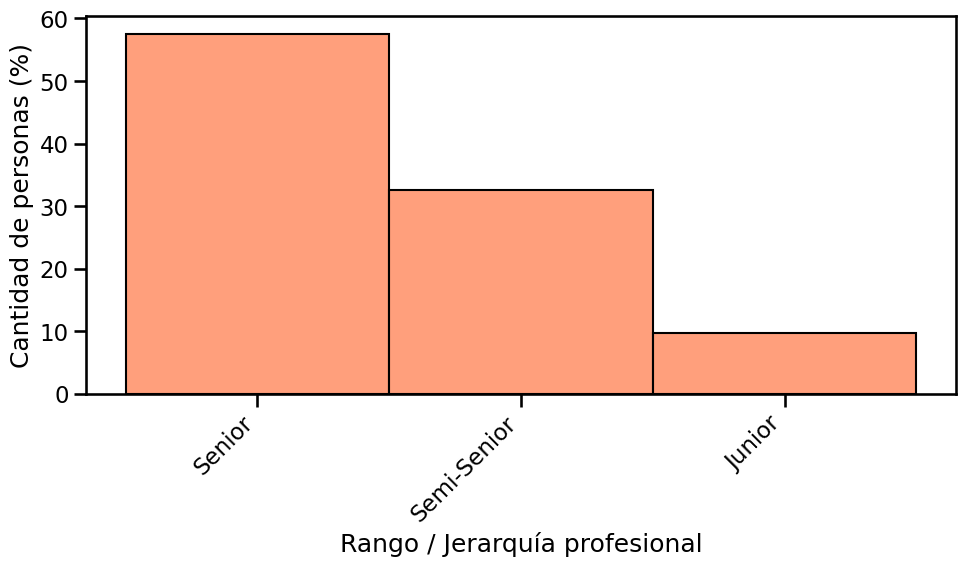

In [18]:
plt.figure(figsize=(10, 6))
seaborn.histplot(data=df_salary_filtered, x='work_seniority', color='coral', stat='percent')
plt.xticks(rotation=45, ha='right') # Rotar los labels del eje x
plt.xlabel('Rango / Jerarquía profesional')
plt.ylabel('Cantidad de personas (%)')
plt.tight_layout() # Evita que los labels se corten al guardar la imagen
plt.show()

Vemos que en nuestra muestra tenemos 3 jerarquias profesionales

- El ~57% (2311 personas) son Seniors
- El ~33% (1310 personas) son Semi-Senior
- El ~10% (393 personas) son Junior

In [19]:
df_salary_filtered['profile_gender'].value_counts()


,count
profile_gender,
Hombre Cis,3128
Mujer Cis,810
Prefiero no decir,41
No binarie,17
Queer,9
Trans,7
Agénero,1


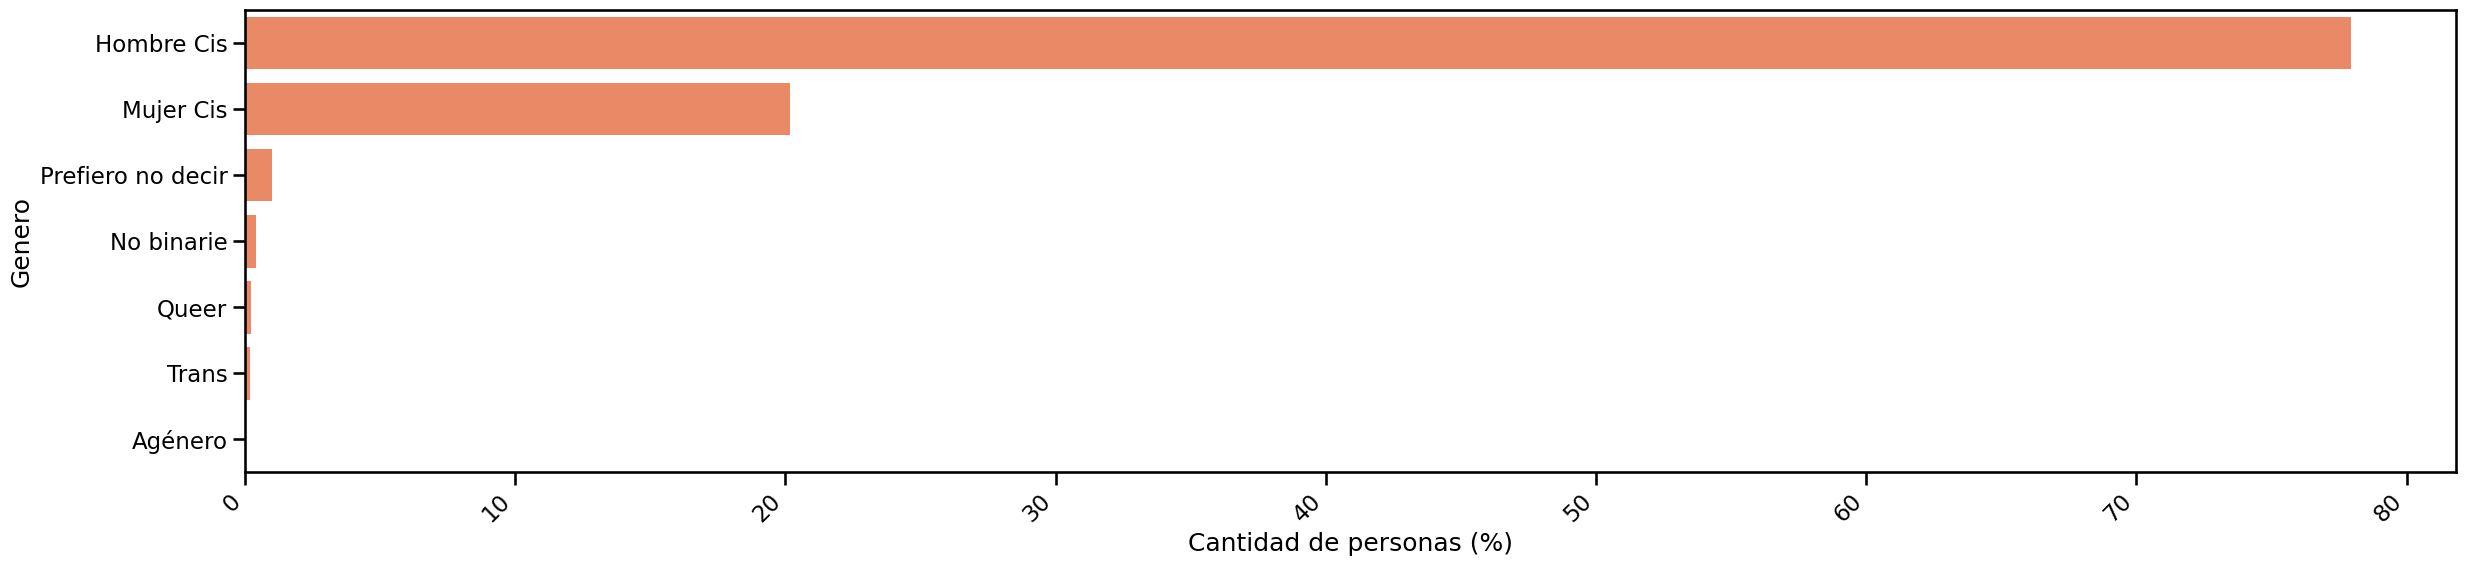

In [20]:
plt.figure(figsize=(25, 6))
seaborn.countplot(y=df_salary_filtered.profile_gender, color='coral', order = df_salary_filtered.profile_gender.value_counts().index ,stat='percent')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Genero')
plt.xlabel('Cantidad de personas (%)')
plt.tight_layout()
plt.show()

En nuestra muestra encontramos que:

- El ~78% (3128 personas) son Hombres Cis
- El ~20% (810 personas) son Mujeres Cis
- El ~0.5% (17 personas) son No binare
- El ~0.2% (9 personas) son Queer
- El ~0.2% (7 personas) son Trans
- El ~0.1% (1 personas) son Agénero

y
- El ~1% (41 personas) prefirieron no dar información de su género


## Ahora vemos las numéricas

###Años de experiencia

In [21]:
df_salary_filtered['profile_years_experience'].describe()

,profile_years_experience
count,4014.000000
mean,9.930244
std,8.155761
min,0.000000
25%,4.000000
50%,7.000000
75%,15.000000
max,48.000000


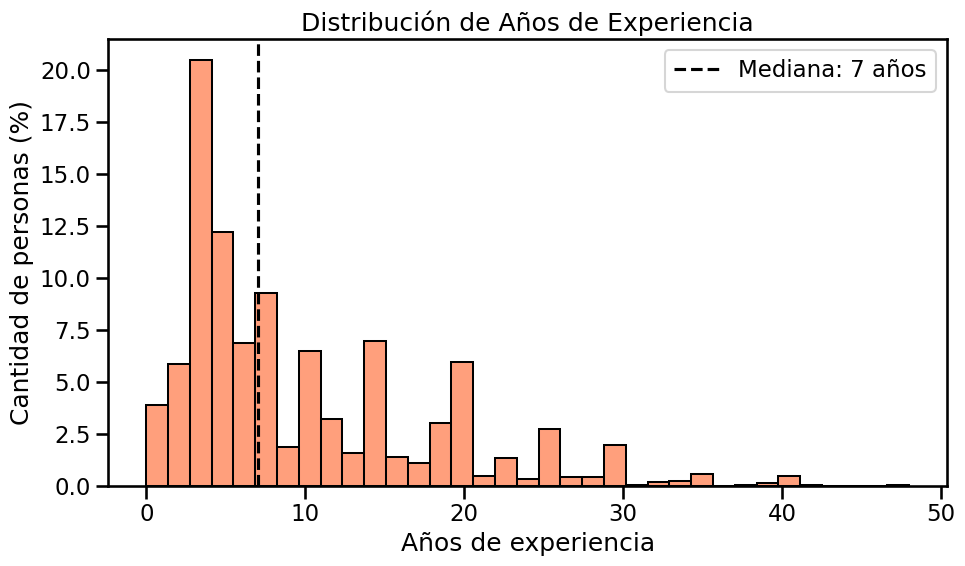

In [22]:
plt.figure(figsize=(10, 6))
seaborn.histplot(data=df_salary_filtered, x='profile_years_experience', color='coral', stat='percent')
plt.xlabel('Años de experiencia')

median_experience = df_salary_filtered['profile_years_experience'].median()
plt.axvline(median_experience, color='k', linestyle='--', label=f'Mediana: {median_experience:.0f} años')

plt.xlabel('Años de experiencia')
plt.ylabel('Cantidad de personas (%)')
plt.title('Distribución de Años de Experiencia')
plt.legend()
plt.tight_layout()
plt.show()

###Edad

In [23]:
df_salary_filtered['profile_age'].describe()

,profile_age
count,4014.000000
mean,37.566268
std,20.264596
min,16.000000
25%,30.000000
50%,36.000000
75%,43.000000
max,999.000000


Vemos que claramente tenemos algún "chistoso/a" que tiene un milenio de edad, para evitar analizar vampiros trabajando, y tambien menores de edad, pensando en analizar la población mayor de edad. Limpiamos los datos en 18 y 70 (uno puede buscar laburar más de la edad de jubilación? #MiPaís)

In [24]:
df_salary_and_age_filtered = df_salary_filtered[(df_salary_filtered.profile_age < 70) & (df_salary_filtered.profile_age >= 18)].copy()

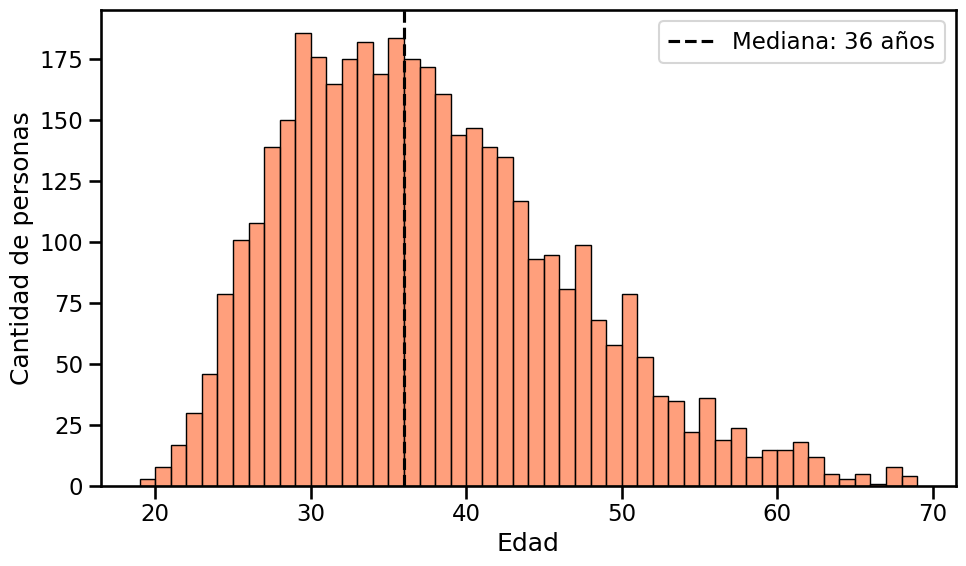

In [25]:
plt.figure(figsize=(10, 6))
seaborn.histplot(data=df_salary_and_age_filtered, x='profile_age', color='coral',bins=50)

median_experience = df_salary_filtered['profile_age'].median()
plt.axvline(median_experience, color='k', linestyle='--', label=f'Mediana: {median_experience:.0f} años')

plt.xlabel('Edad')
plt.ylabel('Cantidad de personas')
plt.legend()

plt.tight_layout()
plt.show()

### Ahora vemos relaciones entre las variables elegidas

### Salario vs Seniority

/tmp/ipykernel_11283/995629257.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  seaborn.boxplot(data=df_salary_and_age_filtered,


Text(0.5, 1.0, 'Salario según seniority')

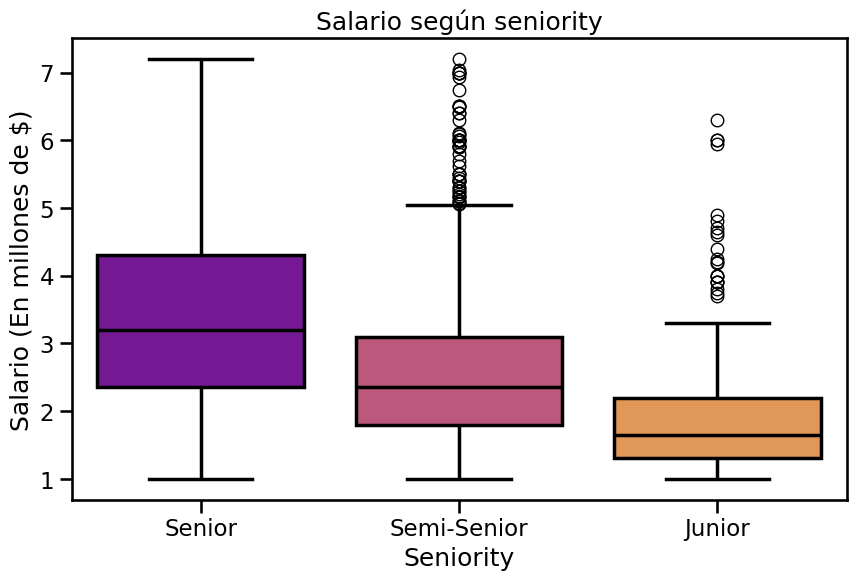

In [26]:
plt.figure(figsize=(10,6))
seaborn.boxplot(data=df_salary_and_age_filtered,
                x='work_seniority',
                y='salary_monthly_NETO',
                linewidth=2.5, # Adjust line thickness
                linecolor='k',  # Set line color
                palette='plasma'
                )

# plt.yscale('log')  # MUY importante por la cola larga
plt.ylabel('Salario (En millones de $)')
plt.xlabel('Seniority')
plt.title('Salario según seniority')

Para analizar la relación entre el salario y el nivel de seniority, se utilizó un boxplot.

Se observa una diferencia clara entre las categorías:

- Los perfiles `Senior` presentan los salarios más altos en promedio, junto con una mayor dispersión
- Los `Semi-Senior` se ubican en un rango intermedio, aunque con varios valores altos que se solapan con los Senior
- Los `Junior` concentran sus salarios en valores más bajos, con menor variabilidad

Además, se observan varios valores atípicos (outliers), especialmente en las categorías `Semi-Senior` y `Junior`, lo que podría indicar que existen casos particulares con salarios más altos de lo esperado para esos niveles.

En general, el gráfico muestra una relación consistente entre el seniority y el salario: a mayor seniority, mayores niveles salariales. Sin embargo, el solapamiento entre categorías sugiere que el seniority no es el único factor que influye en el salario.

### Experiencia vs Seniority

/tmp/ipykernel_11283/1351533515.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = seaborn.boxplot(data=df_salary_and_age_filtered,


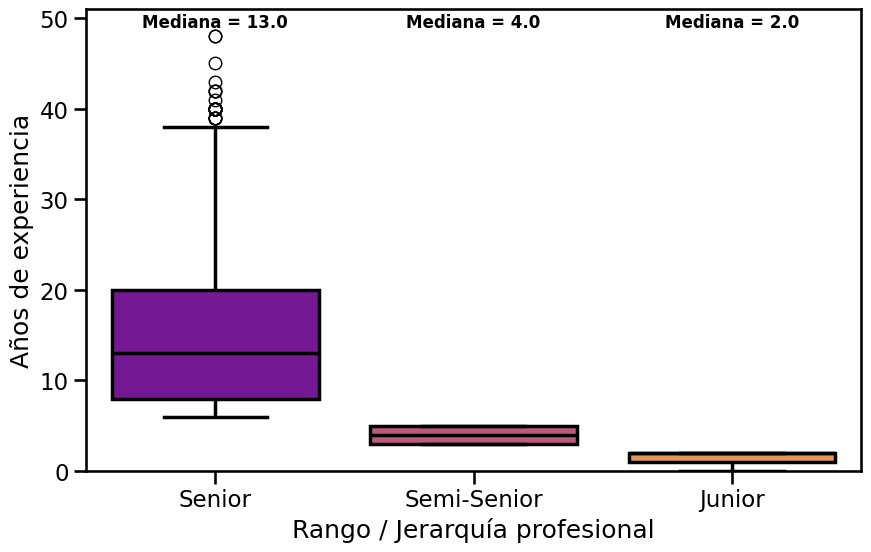

In [27]:
import numpy as np

palette = {
    "Junior": "#4C72B0",        # azul
    "Semi-Senior": "#55A868",   # verde
    "Senior": "#C44E52"         # rojo
}

plt.figure(figsize=(10,6))

ax = seaborn.boxplot(data=df_salary_and_age_filtered,
                 x='work_seniority',
                 y='profile_years_experience',
                 order=["Senior", "Semi-Senior", "Junior"],
                 linewidth=2.5, # Adjust line thickness
                 linecolor='k',  # Set line color
                 palette='plasma')

# Calcular medias
means = df_salary_and_age_filtered.groupby("work_seniority")["profile_years_experience"].median()

# Agregar texto arriba
for i, cat in enumerate(["Senior", "Semi-Senior", "Junior"]):
    mean_val = means[cat]
    ax.text(i,                       # posición en x
            df_salary_and_age_filtered['profile_years_experience'].max() + 1,  # arriba del plot
            f"Mediana = {mean_val:.1f}",
            ha='center',
            fontsize=12,
            fontweight='bold')

plt.ylabel("Años de experiencia")
plt.xlabel('Rango / Jerarquía profesional')
plt.ylim(0, df_salary_and_age_filtered['profile_years_experience'].max() + 3)

plt.show()

Se observan distribuciones acordes a lo esperado: a medida que aumentan los años de experiencia, los perfiles tienden a ubicarse en niveles más altos de rango / jerarquía profesional.

Los perfiles `Junior` se concentran en pocos años de experiencia, los `Semi-Senior` en valores intermedios, y los `Senior` presentan una mayor dispersión, alcanzando los valores más altos.

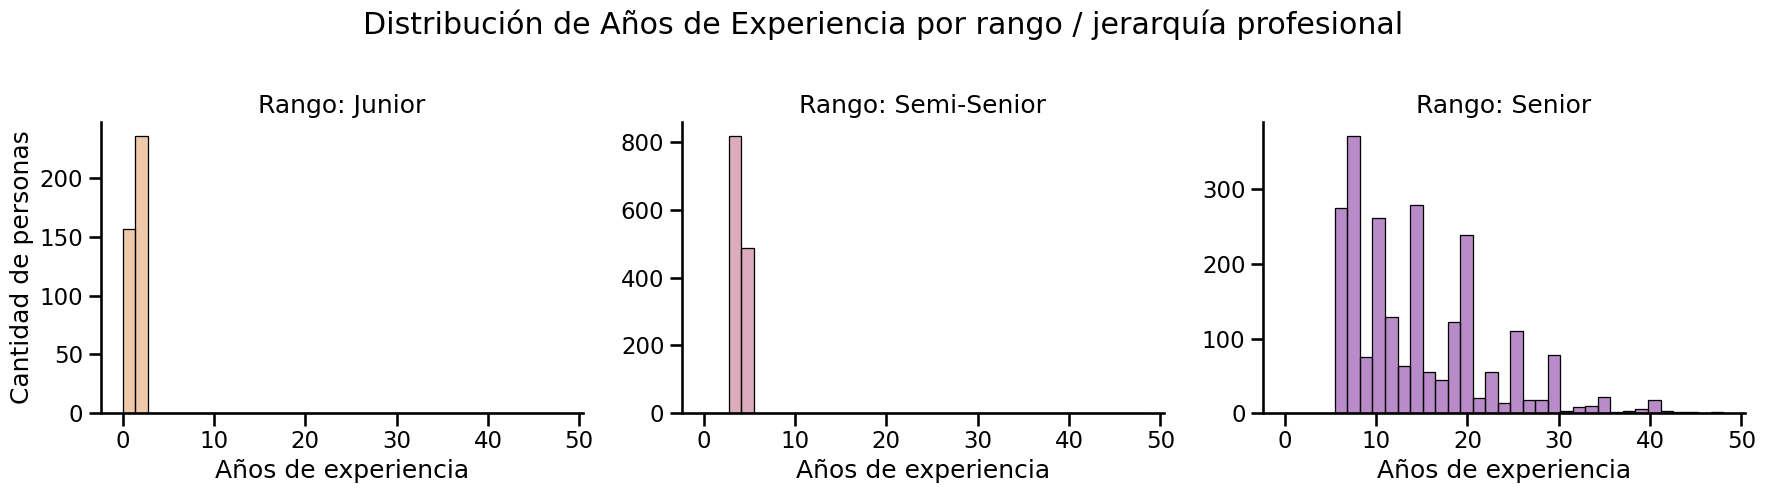

In [28]:
color_palette = {
    'Senior': '#741893',
    'Semi-Senior': '#bb587c',
    'Junior': '#e19757'
}

g = seaborn.displot(data=df_salary_and_age_filtered,
                    x='profile_years_experience',
                    col='work_seniority',
                    hue='work_seniority', # Add hue to apply palette correctly
                    kind='hist',
                    #col_order=['Senior', 'Semi-Senior', 'Junior'],
                    col_order=['Junior', 'Semi-Senior','Senior' ],
                    col_wrap=3, # Display 3 plots per row
                    height=5, aspect=1.2, # Adjust plot size
                    facet_kws={'sharey': False},
                    palette=color_palette,
                    legend=False) # Apply custom palette
g.set_axis_labels('Años de experiencia', 'Cantidad de personas')
g.set_titles('Rango: {col_name}')
plt.suptitle('Distribución de Años de Experiencia por rango / jerarquía profesional', y=1) # main title
plt.tight_layout()
plt.show()

### Salario vs Genero

/tmp/ipykernel_11283/2017116567.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = seaborn.boxplot(data=df_salary_and_age_filtered,


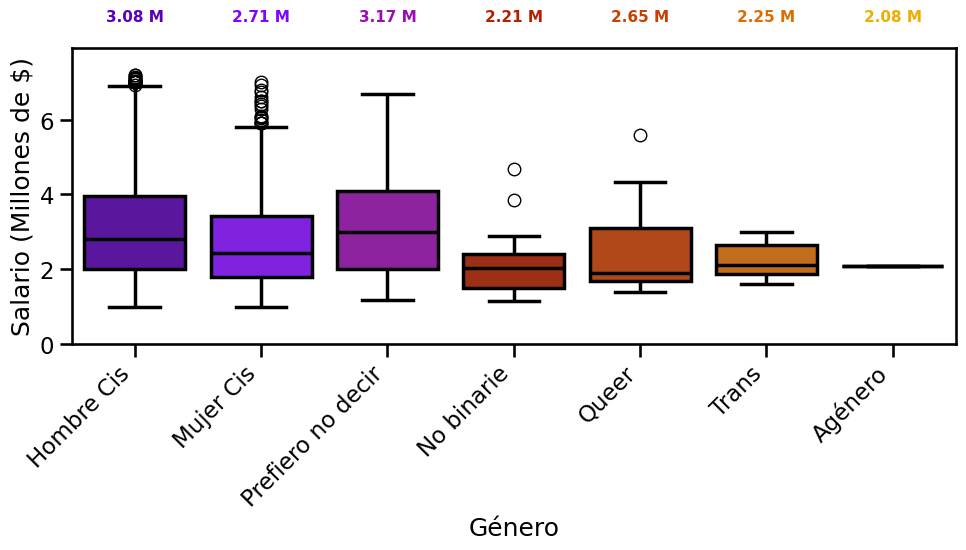

In [29]:
import numpy as np

# Orden (opcional pero recomendable)
order = df_salary_and_age_filtered['profile_gender'].value_counts().index

# Paleta (podés ajustarla si querés)
palette = seaborn.color_palette("gnuplot", len(order))

plt.figure(figsize=(10,6))

ax = seaborn.boxplot(data=df_salary_and_age_filtered,
                 x='profile_gender',
                 y='salary_monthly_NETO',
                 linewidth=2.5, # Adjust line thickness
                 linecolor='k',  # Set line color
                 order=order,
                 palette=palette)

# Calcular medias
means = df_salary_and_age_filtered.groupby("profile_gender")["salary_monthly_NETO"].mean()

# Agregar texto arriba
y_max = df_salary_and_age_filtered['salary_monthly_NETO'].max()

for i, cat in enumerate(order):
    mean_val = means[cat]
    mean_val_millions = mean_val
    ax.text(i,
            y_max * 1.2,   # mejor que + constante cuando estás en log
            f"{mean_val_millions:,.02f} M",
            ha='center',
            fontsize=11,
            fontweight='bold',
            color=palette[i])

plt.xticks(rotation=45, ha='right')
plt.xlabel('Género')
plt.ylabel('Salario (Millones de $)')
plt.ylim(0, y_max * 1.1)

plt.tight_layout()
plt.show()

En este boxplot se puede observar como existe una diferencia clara entre los sueldos de los hombres, los más altos, y los de las mujeres y otras diversidades, sistemáticamente más bajos.

En el caso de las personas que prefieren no decir su género, aunque su sueldo parece ser mayor, como no sabemos a que grupo pertenecen no son representativos de la muestra.

Una pregunta que surge es, ¿Ésta diferencia en salario está presente en todos las jerarquías? Y para responder la pregunta vemos en cada seniority los sueldos de los distintos géneros.

Para facilitar la visualización llamaremos `Diversidades` a los géneros `Trans`, `Queer`, `No binarie` y `Agénero`. Y a las personas que prefirieron no decir su género no las tendrémos en cuenta.

In [30]:
gender_mapping = {
    'Trans': 'Diversidades',
    'Queer': 'Diversidades',
    'No binarie': 'Diversidades',
    'Agénero': 'Diversidades'
}

df_salary_and_age_filtered['profile_gender'] = df_salary_and_age_filtered['profile_gender'].replace(gender_mapping)

print("Updated gender categories:")
display(df_salary_and_age_filtered['profile_gender'].value_counts())

Updated gender categories:


,count
profile_gender,
Hombre Cis,3123
Mujer Cis,808
Prefiero no decir,41
Diversidades,32


/tmp/ipykernel_11283/3472326546.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  seaborn.violinplot(data=df_salary_and_age_filtered[df_salary_and_age_filtered['work_seniority'] == 'Senior'],
/tmp/ipykernel_11283/3472326546.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  seaborn.violinplot(data=df_salary_and_age_filtered[df_salary_and_age_filtered['work_seniority'] == 'Semi-Senior'],
/tmp/ipykernel_11283/3472326546.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  seaborn.violinplot(data=df_salary_and_age_filtered[df_salary_and_age_filtered['work_seniority'] == 'Juni

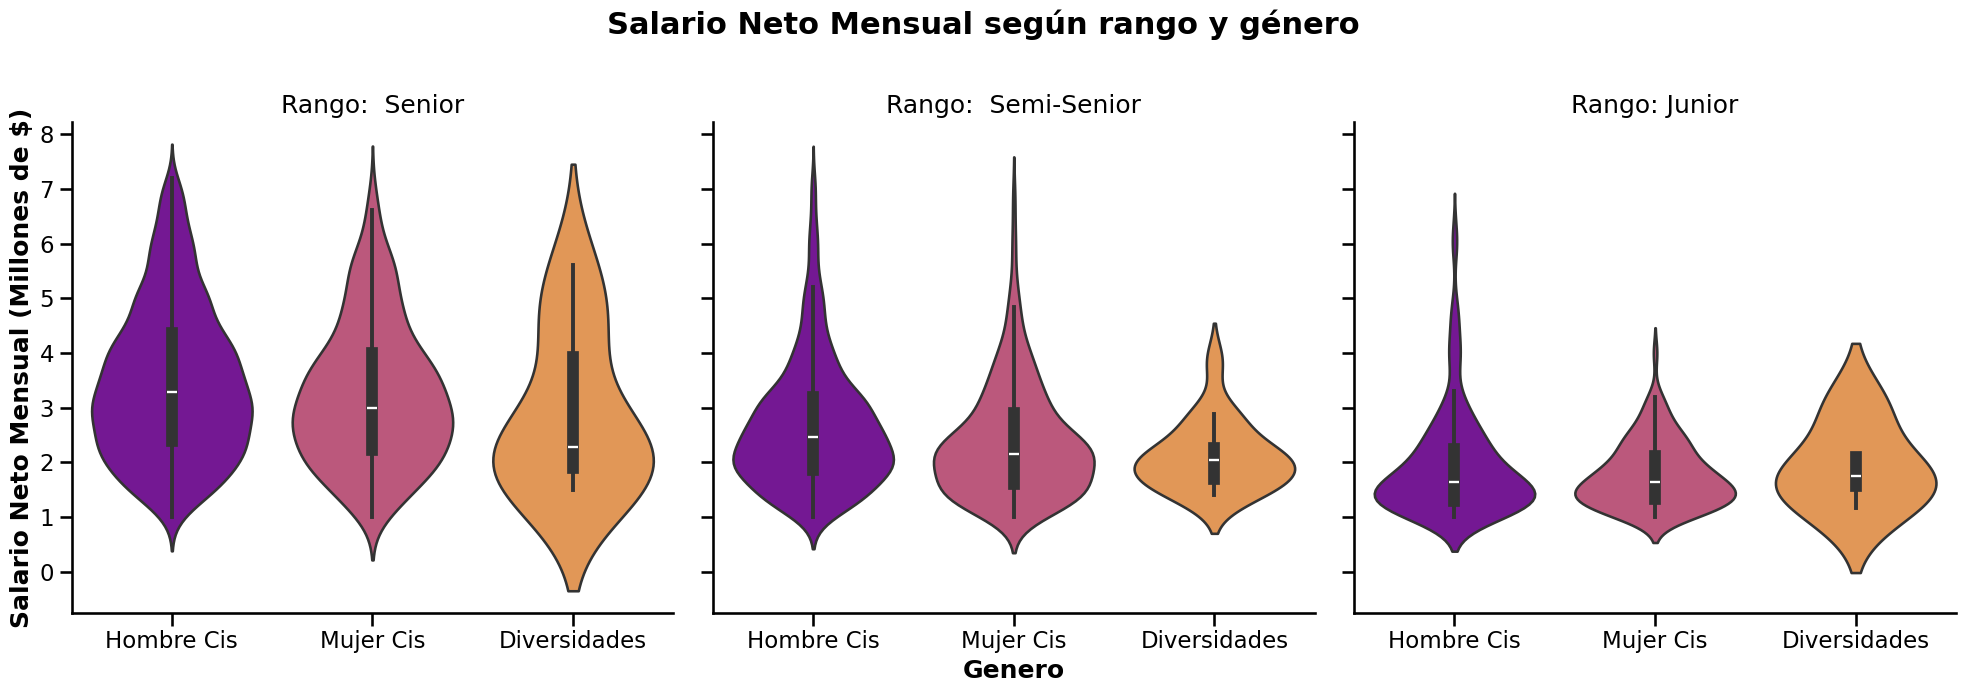

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

# Violin plot for work_seniority
seaborn.violinplot(data=df_salary_and_age_filtered[df_salary_and_age_filtered['work_seniority'] == 'Senior'],
               x='profile_gender',
               y='salary_monthly_NETO',
               ax=axes[0],
               order=["Hombre Cis", "Mujer Cis", "Diversidades"],
               palette='plasma')
axes[0].set_title('Rango:  Senior')
axes[0].set_xlabel('')
axes[0].set_ylabel('Salario Neto Mensual (Millones de $)',fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)


# Violin plot for profile_gender
seaborn.violinplot(data=df_salary_and_age_filtered[df_salary_and_age_filtered['work_seniority'] == 'Semi-Senior'],
               x='profile_gender',
               y='salary_monthly_NETO',
               ax=axes[1],
               order=["Hombre Cis", "Mujer Cis", "Diversidades"],
               palette='plasma')
axes[1].set_title('Rango:  Semi-Senior')
axes[1].set_xlabel('Genero',fontweight='bold')
axes[1].set_ylabel('Salario Neto Mensual',fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

# Violin plot for work_work_modality
seaborn.violinplot(data=df_salary_and_age_filtered[df_salary_and_age_filtered['work_seniority'] == 'Junior'],
               x='profile_gender',
               y='salary_monthly_NETO',
               ax=axes[2],
               order=["Hombre Cis", "Mujer Cis", "Diversidades"],
               palette='plasma')
axes[2].set_title('Rango: Junior')
axes[2].set_xlabel('')
axes[2].set_ylabel('Salario Neto Mensual',fontweight='bold')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Salario Neto Mensual según rango y género',
             fontsize=22, y=1,fontweight='bold')
seaborn.despine()
plt.tight_layout()
plt.show()

Al analizar estas diferencias dentro de cada nivel de rango, se observa que la brecha salarial se mantiene especialmente en los niveles `Semi-Senior` y `Senior`, mientras que en el nivel `Junior` las diferencias son menos marcadas

Los hombres sistemáticamente cobran más que los otros generos.

## b) Asociación

* Necesitamos decidir si sacar o no la columna de salario bruto. Para hacer la encuesta más simple.
¿Existe una correlación entre el salario bruto y el neto? Que abordaje y medidas usaría



Para saber si existe una correlación entre el salario bruto y neto graficamos una variable contra la otra con un scatter plot

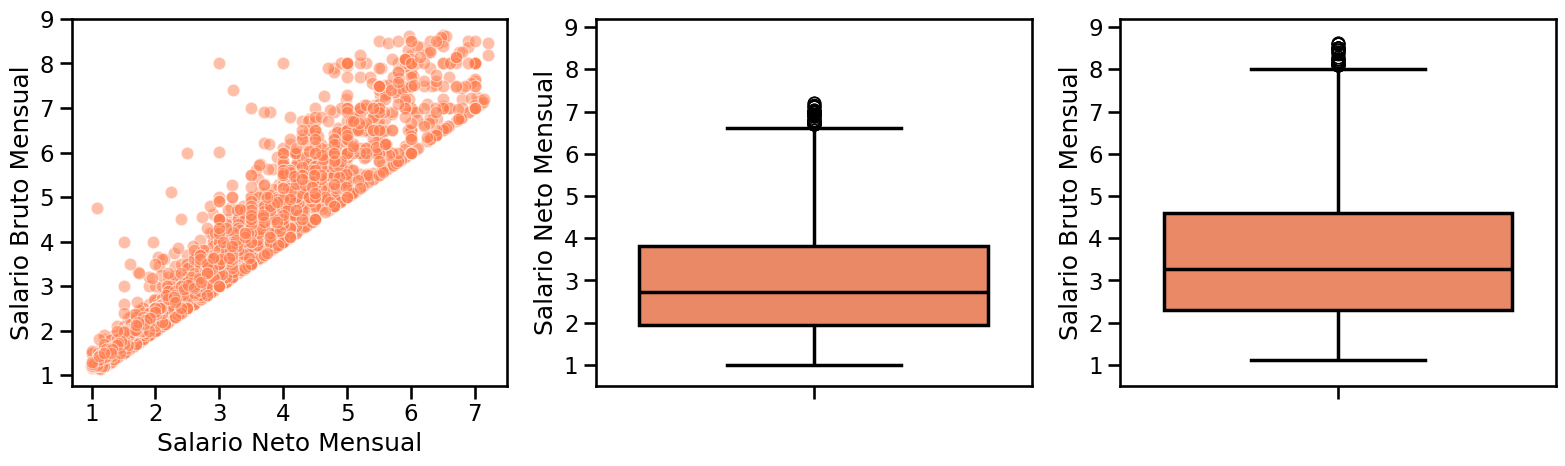

In [32]:
fig, ax = plt.subplots(ncols=3, figsize=(16, 5))

seaborn.scatterplot(data=df_salary_filtered, x=df_salary_filtered.salary_monthly_NETO, y=df_salary_filtered.salary_monthly_BRUTO, alpha=0.5, ax=ax[0], color='coral')
ax[0].set_xlabel('Salario Neto Mensual')
ax[0].set_ylabel('Salario Bruto Mensual')
ax[0].xaxis.set_major_locator(MultipleLocator(1))
ax[0].yaxis.set_major_locator(MultipleLocator(1))

seaborn.boxplot(data=df_salary_filtered, y=df_salary_filtered.salary_monthly_NETO, ax=ax[1], linewidth=2.5, linecolor='k', color='coral')
ax[1].set_ylabel('Salario Neto Mensual')
ax[1].set_ylim(0.5, 9.2)
ax[1].yaxis.set_major_locator(MultipleLocator(1))

seaborn.boxplot(data=df_salary_filtered, y=df_salary_filtered.salary_monthly_BRUTO, ax=ax[2], linewidth=2.5, linecolor='k', color='coral')
ax[2].set_ylabel('Salario Bruto Mensual')
ax[2].set_ylim(0.5, 9.2)
ax[2].yaxis.set_major_locator(MultipleLocator(1))

plt.tight_layout()
plt.show()


Calculamos el coeficiente de correlación lineal de Pearson

In [33]:
correlation = df_salary_filtered['salary_monthly_NETO'].corr(df_salary_filtered['salary_monthly_BRUTO'])
print('Coeficiente de Pearson',correlation)

Coeficiente de Pearson 0.9617771646901576


De este gráfico y del valor de coeficiente de Pearson (muy cercano a 1) podemos concluir que el salario neto y el salario bruto están correlacionados. Sin embargo vemos que hay algunos outliers por arriba de ciertos salarios (ver boxplots). Por debajo no hay outliers porque hemos eliminado aquellos salarios netos que son mayores a los brutos porque consideramos que no tiene sentido. Los outliers en salario bruto puede deberse a diferentes regímenes de impuestos, en Argentina hay muchos trabajadores monotribustistas que pagan el mínimo de impuestos, y esto se puede comprobar también en el ensanchamiento de la dispersión de datos hacia valores de salarios netos más altos. Mas allá de los outliers, consideramos que podríamos eliminar la columna salario bruto y aclarar en la encuesta que el salario neto es lo que se recibe en mano.

## c) Densidad condicional

Estudie la distribución del salario según el nivel de estudio.

Separe la población según el nivel de estudio (elija dos subpoblaciones numerosas) y grafique de manera comparativa ambos histogramas de la variable `'salary_monthly_NETO'`
¿Considera que ambas variables son independientes?
¿Qué analizaría al respecto?

Calcule medidas de centralización y dispersión para cada subpoblación






La variable que determina el nivel de estudio es `profile_studies_level`. Veamos cuales son estas categorias

In [34]:
df_salary_filtered.profile_studies_level.value_counts()

,count
profile_studies_level,
Universitario,955
Terciario,220
Posgrado/Especialización,90
Maestría,88
Secundario,50
Doctorado,21
Posdoctorado,6


Text(0, 0.5, 'Nivel de estudios')

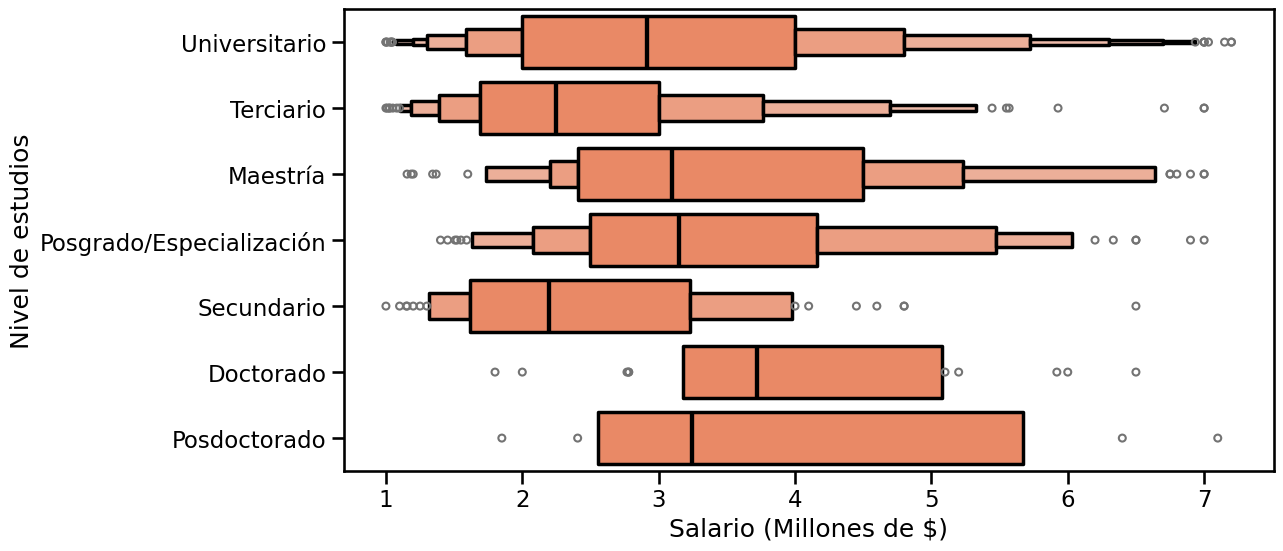

In [35]:
plt.figure(figsize=(12, 6))
seaborn.boxenplot(data=df_salary_filtered, x=df_salary_filtered['salary_monthly_NETO'], y=df_salary_filtered['profile_studies_level'], color='coral', linewidth=2.5, linecolor='k')
plt.ticklabel_format(style='plain', axis='x')
plt.xlabel('Salario (Millones de $)')
plt.ylabel('Nivel de estudios')

Vamos a considerar los niveles de estudios universitario y terciario, por ser los más populares y con distribuciones diferentes

Salario promedio Universitarios 3.1043396683350784
Salario promedio Terciarios 2.505348187090909


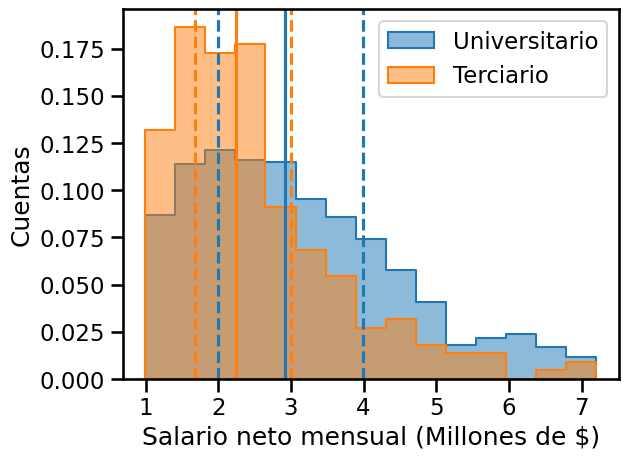

In [36]:
# Normalizamos cada una de las categorias por el numero total de cuentas en cada una de ellas, para facilitar la comparación
total_counts = df_salary_filtered.groupby("profile_studies_level").size()
weights = {
    "Universitario": 1 / total_counts["Universitario"],
    "Terciario": 1 / total_counts["Terciario"]
}

# Fijamos un rango de salarios, el mismo para ambas categorías
min_salary = df_salary_filtered.salary_monthly_NETO.min()
max_salary = df_salary_filtered.salary_monthly_NETO.max()

for level, weight in weights.items():
    subset = df_salary_filtered[df_salary_filtered.profile_studies_level == level]
    seaborn.histplot(
        data=subset,
        x="salary_monthly_NETO",
        stat="count",
        weights=[weight] * len(subset),
        bins=15,
        alpha=0.5,
        element="step",
        label=level,
        binrange=(min_salary, max_salary)
    )
plt.legend()
plt.xlabel("Salario neto mensual (Millones de $)")
plt.ylabel("Cuentas")

plt.axvline(df_salary_filtered[df_salary_filtered.profile_studies_level == 'Universitario'].salary_monthly_NETO.median(),linestyle='-')
plt.axvline(df_salary_filtered[df_salary_filtered.profile_studies_level == 'Universitario'].salary_monthly_NETO.quantile(.25), linestyle='--')
plt.axvline(df_salary_filtered[df_salary_filtered.profile_studies_level == 'Universitario'].salary_monthly_NETO.quantile(.75), linestyle='--')
plt.axvline(df_salary_filtered[df_salary_filtered.profile_studies_level == 'Terciario'].salary_monthly_NETO.median(),linestyle='-',color='tab:orange')
plt.axvline(df_salary_filtered[df_salary_filtered.profile_studies_level == 'Terciario'].salary_monthly_NETO.quantile(.25), linestyle='--',color='tab:orange')
plt.axvline(df_salary_filtered[df_salary_filtered.profile_studies_level == 'Terciario'].salary_monthly_NETO.quantile(.75), linestyle='--',color='tab:orange')

print('Salario promedio Universitarios',df_salary_filtered[df_salary_filtered.profile_studies_level == 'Universitario'].salary_monthly_NETO.mean())
print('Salario promedio Terciarios',df_salary_filtered[df_salary_filtered.profile_studies_level == 'Terciario'].salary_monthly_NETO.mean())


De este histograma podemos ver que ambas distribuciones son asimétricas pero los salarios de las personas que tienen formación terciaria están mas concentrados en la parte izquierda (salarios menores). Prácticamente todo el rango intercuatilico de las personas que tienen formación terciaria está por debajo de la mediana de los que tienen formación universitaria. Dicho de otra forma, el 50% de las personas que tienen formación universitaria ganan más que el 75% de los que tienen formación terciaria.

Para ver si el salario depende del nivel de estudio, calculamos la probabilidad condicional. Vamos a utilizar el salario neto promedio como referencia y ver si las personas con estudios universitario y terciario están por arriba de ese salario.

In [37]:
# Condicion de salario neto por arriba del promedio
sal_above_avg = df_salary_filtered['salary_monthly_NETO'] >= df_salary_filtered['salary_monthly_NETO'].mean() #lista de booleanos
# Personas que tienen formación universitaria y terciaria
univ = df_salary_filtered.profile_studies_level ==  'Universitario' #lista debooleanos
terc = df_salary_filtered.profile_studies_level ==  'Terciario' #lista debooleanos

# Personas que tienen formación universitaria y cobran más que el promedio
intersection_univ = len(df_salary_filtered[sal_above_avg & univ])
# Personas que tienen formación terciaria y cobran más que el promedio
intersection_terc = len(df_salary_filtered[sal_above_avg & terc])

univ_count = len(df_salary_filtered[univ])
terc_count = len(df_salary_filtered[terc])

# Probabilidad de tener salario por arriba del promedio
prob_above_avg = len(df_salary_filtered[sal_above_avg]) / len(df_salary_filtered)
# Probabilidad de tener salario por arriba del promedio teniendo formación universitaria
prob_cond_above_avg_univ=len(df_salary_filtered[sal_above_avg & univ])/len(df_salary_filtered[univ])
# Probabilidad de tener salario por arriba del promedio teniendo formación terciaria
prob_cond_above_avg_terc=len(df_salary_filtered[sal_above_avg & terc])/len(df_salary_filtered[terc])

print(f'Probabilidad de cobrar mas que el promedio teniendo formación universitaria: {prob_cond_above_avg_univ:.2f}')
print(f'Probabilidad de cobrar mas que el promedio teniendo formación terciaria: {prob_cond_above_avg_terc:.2f}')
print(f'Probabilidad de tener un salario por arriba del promedio: {prob_above_avg:.2f}')

Probabilidad de cobrar mas que el promedio teniendo formación universitaria: 0.46
Probabilidad de cobrar mas que el promedio teniendo formación terciaria: 0.25
Probabilidad de tener un salario por arriba del promedio: 0.41


Al analizar los datos, rápidamente podemos observar que el sueldo no es independiente de la formación académica. Si tomamos al azar una persona de la encuesta, esta tendrá un 41% de probabilidad de ganar por encima de la media. Es decir, en rasgos generales casi dos de cada cinco personas ganan mas que el salario promedio.
Sin embargo, cuando filtramos la muestra por nivel de estudio esta probabilidad cambia. Para aquellas personas que poseen estudios universitarios la probabilidad de ganar sueldos que superen la media aumenta a 46%. Mientras que para las personas que poseen estudios terciarios la probabilidad de ganar por encima de la media cae considerablamente al 25%.

Entonces, podemos concluir que el salario depende directamente de la formación. Estudiar una carrera universitaria prácticamente duplica tus chances de estar entre los mejores salarios frente a una formación terciaria.

## d) Densidad Conjunta condicional

Elija dos variables numéricas y una categórica.
Estudie la dispersión (scatterplot) de las dos variables discriminando en color por la variable categórica (ayuda: hue en seaborn)

Escoguimos:
- `salary_monthly_NETO`
- `profile_age`
- `work_seniority`

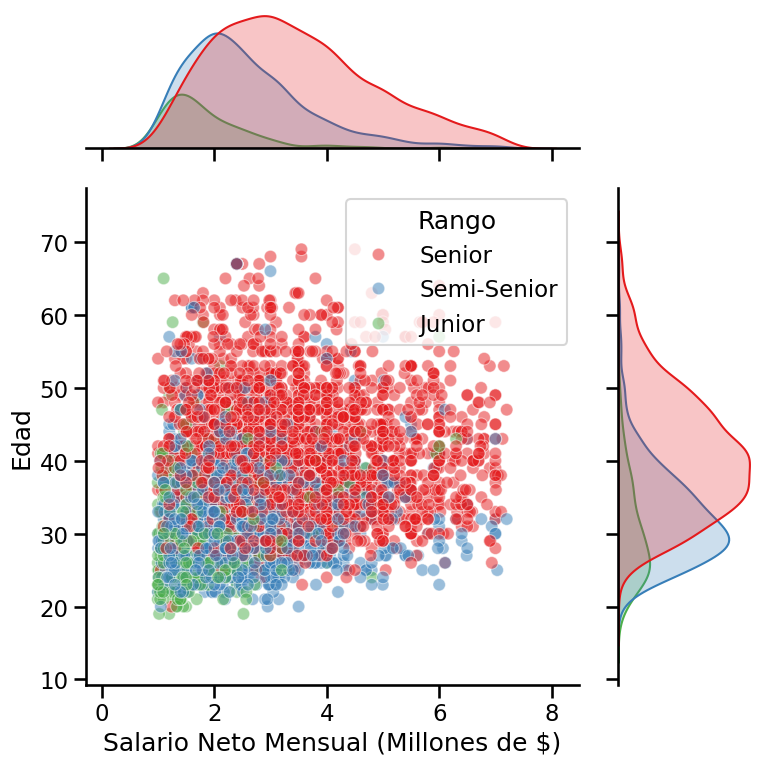

In [38]:
g = seaborn.jointplot(
    data=df_salary_and_age_filtered,
    x="salary_monthly_NETO",
    y="profile_age",
    hue="work_seniority",
    kind='scatter',
    palette='Set1',
    alpha=0.5,
    height=8,
    ratio=3
    )

# plt.legend(
#     loc='lower left',
#     bbox_to_anchor=(0.04, 0.9, 1, 0.3),
#     mode="expand",
#     borderaxespad=0,
#     ncol=3)

# Set the legend title
if g.ax_joint.legend_:
   g.ax_joint.legend_.set_title('Rango')

plt.xlabel('Salario Neto Mensual (Millones de $)')
plt.ylabel('Edad')
plt.tight_layout()
plt.show()

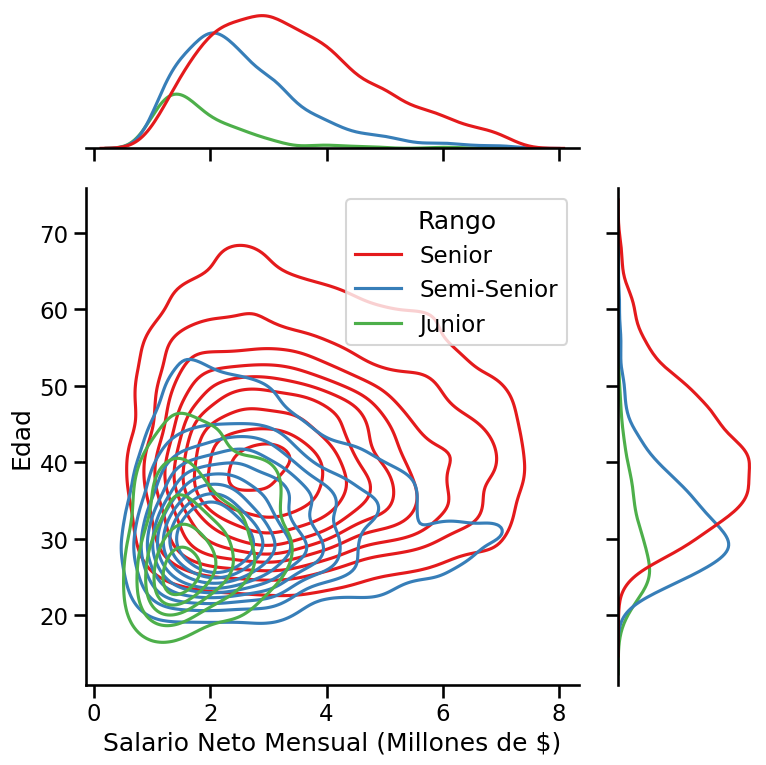

In [39]:
g = seaborn.jointplot(
    data=df_salary_and_age_filtered,
    x="salary_monthly_NETO",
    y="profile_age",
    hue="work_seniority",
    kind="kde",
    palette='Set1',
    height=8,
    ratio=3
)


# Set the legend title
if g.ax_joint.legend_:
    g.ax_joint.legend_.set_title('Rango')

plt.xlabel('Salario Neto Mensual (Millones de $)')
plt.ylabel('Edad')
plt.tight_layout()
plt.show()

Para analizar la relación entre salario y edad, se utilizó un scatterplot diferenciando por nivel de seniority.

En el gráfico de dispersión se observa una tendencia general donde, a mayor seniority, los salarios tienden a ser más altos. Sin embargo, existe una dispersión considerable dentro de cada grupo. La edad parece tener cierta relación con el salario, pero no es determinante: se observan personas relativamente jóvenes con salarios altos y personas de mayor edad con salarios más moderados.

Para complementar esta visualización, se analizaron los contornos de densidad conjunta, que permiten identificar mejor las regiones donde se concentran los datos.

A partir de estos, se observa que:

- Los perfiles `Junior` están fuertemente concentrados en edades más bajas y salarios menores
- Los `Semi-Senior` se distribuyen en una región intermedia tanto en edad como en salario
- Los `Senior` presentan una mayor dispersión, abarcando un rango más amplio de edades y alcanzando los valores más altos de salario

En comparación con el scatterplot, los gráficos de densidad permiten visualizar de forma más clara las zonas de mayor concentración, reduciendo el ruido visual.

En general, los resultados sugieren que el seniority está asociado tanto al salario como, en menor medida, a la edad. Sin embargo, la variabilidad dentro de cada grupo indica que estas relaciones no son estrictas y pueden estar influenciadas por otros factores no considerados en este análisis.

Finalmente, es importante remarcar que estas conclusiones se basan únicamente en la muestra analizada, por lo que no necesariamente representan el comportamiento de toda la población.


## Conclusiones Generales Ej.2

Para explorar la base de datos y detectar patrones o asociaciones, combinamos herramientas de limpieza, estadística descriptiva y visualización, aplicándolas según el tipo de variables analizadas y según la pregunta a responder.

En una primera etapa, realizamos una exploración general de los datos, identificando las variables relevantes y evaluando la calidad de los mismos. En este proceso filtramos valores inconsistentes (por ejemplo, edades irreales) y trabajamos sobre subconjuntos de datos más representativos.

Luego, analizamos las variables de manera individual. Para las variables categóricas, gráficos de conteo permiten entender la composición de la muestra (como en el caso de seniority y género). Para las variables numéricas, empleamos histogramas y estadísticos descriptivos, como medianas, que nos permiten caracterizar distribuciones, detectar asimetrías y reconocer la presencia de valores extremos.

Al estudiar relaciones entre variables, adaptamos las herramientas al tipo de datos. Para analizar salario en función de variables categóricas como seniority o género, utilizamos boxplots y violin plots, lo que permitió comparar distribuciones y visualizar diferencias entre grupos. En estos casos observamos, por ejemplo, una clara relación entre seniority y salario, así como desigualdades sistemáticas entre géneros.

Para relaciones entre variables numéricas, como salario bruto y neto, utilizamos scatter plots junto con el coeficiente de correlación de Pearson, lo que evidenció una fuerte asociación lineal entre ambas variables. Además, complementamos los gráficos de dispersión con visualizaciones de densidad para identificar regiones de mayor concentración de datos y reducir el ruido visual.

Finalmente, al analizar distribuciones condicionadas (por ejemplo, salario según nivel de estudios), combinamos histogramas comparativos con medidas estadísticas y probabilidades condicionales. Esto permitió no solo describir diferencias entre subpoblaciones, sino también evaluar si ciertas variables son independientes o están asociadas.

En conjunto, el uso articulado de estas herramientas nos permitió no solo describir los datos, sino también identificar patrones relevantes y relaciones significativas entre variables, siempre teniendo en cuenta las limitaciones propias de la muestra analizada.